# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subata24/ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.


## 1. Question

*The research question and the decision it supports.*

###Which content pages are most likely to be declining in organic search performance, and should therefore be prioritized for refresh — supporting a content editor's decision of where to spend limited update effort first.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank internship warehouse (Hugging Face, `FlyRank/internship-warehouse`, gated access).

**Tables:** `fact_content_daily_performance` (daily GSC/GA4 metrics, one row per client × content × day) and `dim_content` (static page-level metadata: word count, search volume, content creation date).

**Date windows:** Development and evaluation were performed using `month=2026-02` and `month=2026-03`. February was used as the "before" snapshot to construct all predictive features, while March was used only to define the target variable (whether a page declined in clicks). This ensures that all features are available before the prediction window and prevents future information from leaking into model training.

**Grain:** One row = one content page (a client + content identifier pair), summarized at the month level from daily source rows.

**Exclusions (with why):**
- Page-months with no GSC data available (`gsc_data_available` false) — no way to measure clicks, so no way to measure decline.
- Pages with fewer than 5 clicks in February — near-zero traffic makes "decline" mechanically undefined (a page with 0 clicks cannot go lower), so measuring decline on it produces a floor artifact rather than a real signal.
- Editorial/system metadata (e.g. which AI tool generated a page, whether a page has already been marked eligible for optimization) — these risk encoding a human decision about this exact question, rather than describing the page's organic performance.

All identifiers used throughout (client and content references) are salted, namespaced hash keys — used only for grouping and joining, never as model features, and no raw client names, domains, or query text appear anywhere in this work.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [1]:
%pip install -q duckdb huggingface_hub

import duckdb, os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql("CREATE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{}');".format(os.environ["HF_TOKEN"]))

MIN_CLICKS_FEB = 5

label_df = con.sql(f"""
WITH feb AS (
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_feb
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/data_0.parquet'
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),
mar AS (
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_mar
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    mar.client_hash_id,
    mar.content_hash_id,
    feb.clicks_feb,
    mar.clicks_mar,
    CASE WHEN mar.clicks_mar < feb.clicks_feb THEN 1 ELSE 0 END AS declined
FROM mar
JOIN feb ON mar.client_hash_id = feb.client_hash_id AND mar.content_hash_id = feb.content_hash_id
WHERE feb.clicks_feb >= {MIN_CLICKS_FEB}
""").df()

print("Rows after clicks_feb >= 5 filter:", label_df.shape)
print("Decline rate:", label_df["declined"].mean())
print("Min clicks_feb in data:", label_df["clicks_feb"].min())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows after clicks_feb >= 5 filter: (21776, 5)
Decline rate: 0.4395205731080088
Min clicks_feb in data: 5.0


In [4]:
con.register("label_df_tbl", label_df)

features_df = con.sql("""
WITH feb_metrics AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) AS avg_position_feb,
        SUM(sessions_organic) AS sessions_organic_feb,
        SUM(ga4_engaged_sessions) AS engaged_sessions_feb,
        SUM(gsc_clicks) AS feb_clicks,
        SUM(gsc_impressions) AS feb_impressions
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/data_0.parquet'
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    fm.client_hash_id,
    fm.content_hash_id,
    fm.avg_position_feb,
    fm.sessions_organic_feb,
    fm.engaged_sessions_feb,
    dc.word_count,
    dc.search_volume,
    DATE_DIFF('day', dc.content_created_date, DATE '2026-03-01') AS content_age_days,
    CASE WHEN fm.feb_impressions > 0 THEN fm.feb_clicks * 1.0 / fm.feb_impressions ELSE NULL END AS ctr,
    CASE
        WHEN fm.avg_position_feb <= 3 THEN 0.25
        WHEN fm.avg_position_feb <= 10 THEN 0.05
        ELSE 0.01
    END AS expected_ctr
FROM feb_metrics fm
JOIN 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet' dc
    ON fm.client_hash_id = dc.client_hash_id AND fm.content_hash_id = dc.content_hash_id
JOIN label_df_tbl l
    ON fm.client_hash_id = l.client_hash_id AND fm.content_hash_id = l.content_hash_id
WHERE dc.content_created_date IS NOT NULL
""").df()

features_df["ctr_gap"] = features_df["ctr"] - features_df["expected_ctr"]

print(features_df.shape)
features_df.isna().sum()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(21776, 11)


,0
client_hash_id,0
content_hash_id,0
avg_position_feb,0
sessions_organic_feb,10561
engaged_sessions_feb,10561
word_count,3569
search_volume,289
content_age_days,0
ctr,0
expected_ctr,0


In [5]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

merged = label_df.merge(features_df, on=["client_hash_id", "content_hash_id"])
merged = merged.dropna(subset=["avg_position_feb", "word_count", "search_volume"])

feature_cols = ["avg_position_feb", "sessions_organic_feb", "engaged_sessions_feb",
                "word_count", "search_volume", "content_age_days", "ctr_gap"]

X = merged[feature_cols].fillna(0)
y = merged["declined"]
groups = merged["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Overlap check (should be 0):", len(set(merged.iloc[train_idx]['client_hash_id']) & set(merged.iloc[test_idx]['client_hash_id'])))
print("Base rate (test):", y_test.mean())

Train: (7210, 7) Test: (10747, 7)
Overlap check (should be 0): 0
Base rate (test): 0.41825625756024937


In [6]:
merged_test = merged.iloc[test_idx].copy()

# Baseline rule (same logic as Week 4)
merged_test["stale_flag"] = (merged_test["content_age_days"] >= 90).astype(int)
merged_test["low_ctr_flag"] = np.where(
    merged_test["ctr_gap"].isna(), 0,
    (merged_test["ctr_gap"] < -0.02).astype(int)
)
merged_test["baseline_score"] = merged_test["stale_flag"] + merged_test["low_ctr_flag"]

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

baseline_auc = roc_auc_score(y_test, merged_test["baseline_score"])

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Baseline AUC:", baseline_auc)
print("Logistic Regression AUC:", logreg_auc)
print("Random Forest AUC:", rf_auc)

import pandas as pd
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature importances:\n", importances)

Baseline AUC: 0.5322760876697432
Logistic Regression AUC: 0.5209984506848798
Random Forest AUC: 0.5047101457010954

Feature importances:
                 feature  importance
5      content_age_days    0.338231
3            word_count    0.222520
6               ctr_gap    0.160860
0      avg_position_feb    0.110306
1  sessions_organic_feb    0.086463
4         search_volume    0.053792
2  engaged_sessions_feb    0.027828


In [7]:
def precision_at_k(y_true, y_scores, k):
    order = np.argsort(-y_scores)
    top_k = order[:k]
    return y_true.iloc[top_k].mean()

logreg_scores = logreg.predict_proba(X_test)[:, 1]
rf_scores = rf.predict_proba(X_test)[:, 1]
baseline_scores = merged_test["baseline_score"].values

results = []
for k in [20, 50, 100]:
    results.append({
        "k": k,
        "baseline_precision": precision_at_k(y_test, baseline_scores, k),
        "logreg_precision": precision_at_k(y_test, logreg_scores, k),
        "rf_precision": precision_at_k(y_test, rf_scores, k),
    })

precision_table = pd.DataFrame(results)
print(precision_table)
print("\nBase rate (test):", y_test.mean())

     k  baseline_precision  logreg_precision  rf_precision
0   20                0.15               0.8          0.15
1   50                0.38               0.6          0.26
2  100                0.41               0.5          0.35

Base rate (test): 0.41825625756024937


In [8]:
top20_logreg = merged_test.iloc[np.argsort(-logreg_scores)[:20]]
print(top20_logreg["client_hash_id"].value_counts())
print(top20_logreg[["client_hash_id", "declined"]])

client_hash_id
client_23a62021009f63c4    14
client_73cda7b4e4f265ea     6
Name: count, dtype: int64
                client_hash_id  declined
5441   client_23a62021009f63c4         1
16097  client_23a62021009f63c4         1
16444  client_23a62021009f63c4         1
5064   client_23a62021009f63c4         1
16284  client_23a62021009f63c4         1
16105  client_23a62021009f63c4         0
16492  client_23a62021009f63c4         1
1586   client_23a62021009f63c4         1
15878  client_23a62021009f63c4         1
16148  client_23a62021009f63c4         1
5309   client_23a62021009f63c4         1
5426   client_23a62021009f63c4         1
18576  client_73cda7b4e4f265ea         0
16467  client_23a62021009f63c4         1
7630   client_73cda7b4e4f265ea         1
7847   client_73cda7b4e4f265ea         1
7673   client_73cda7b4e4f265ea         0
7671   client_73cda7b4e4f265ea         0
1421   client_23a62021009f63c4         1
359    client_73cda7b4e4f265ea         1


## 4. Results (vs baseline)
*Model vs baseline on the same split. The honest table.*

##**AUC** (test base rate: 0.418):

| Method | AUC |
|---|---|
| Baseline (Week-4 rule) | 0.532 |
| Logistic Regression | 0.521 |
| Random Forest | 0.505 |

All three methods perform close to chance level. The baseline achieves an AUC of 0.532, while Logistic Regression (0.521) and Random Forest (0.505) remain only marginally above random guessing. None of the methods demonstrate strong discriminative ability for identifying declining pages.

##**Precision@K** (test base rate: 0.418):

| K   | Baseline | Logistic Regression | Random Forest |
| --- | -------- | ------------------- | ------------- |
| 20  | **0.15** | **0.80**            | **0.15**      |
| 50  | **0.38** | **0.60**            | **0.26**      |
| 100 | **0.41** | **0.50**            | **0.35**      |


The k=20 numbers should not be trusted at face value: with only 12 clients in the test set, Logistic Regression's top-20 predictions remain highly concentrated within a small number of clients. This makes the very high Precision@20 likely reflect client concentration rather than genuine ranking ability. At larger values of K (50 and 100), the precision values move much closer to the test base rate (0.418), which agrees with the AUC results: none of the evaluated methods provides strong discrimination once the floor-effect correction is applied.

## 5. Limitations

*What this work cannot claim.*

**No method beats chance once the floor-effect artifact is removed.** The central finding of this capstone is negative: after correcting for a mechanical confound (pages with near-zero February clicks cannot, by construction, be labeled "declined"), the baseline rule, Logistic Regression, and Random Forest all score within noise of AUC 0.50 on a held-out, client-grouped test set. This work cannot claim to predict which pages will decline in organic clicks month-over-month using the features tested here (ranking position, organic sessions, engaged sessions, word count, search volume, content age, CTR-vs-position gap).

**Small test set, sensitive to client concentration.** The test split contains only 12 distinct clients. Ranking metrics computed on small top-K slices (e.g. precision@20) can be dominated by a single client's pages and swing dramatically without reflecting a real, generalizable pattern — demonstrated directly in Section 4, where 70% of one model's top-20 picks came from one client. Any ranking metric at small K should be treated with skepticism unless it holds consistently across a much larger and more diverse client set.

**Reduced dataset from the floor-effect fix.** Filtering to pages with at least 5 February clicks removed roughly 84% of the original candidate pages (134,238 → 21,776). The population this work describes is "pages with meaningful existing traffic," not all content pages — very low-traffic pages are excluded entirely, and nothing here claims to say anything about their likelihood of decline.

**Proxy label, not ground truth.** "Declined" is defined purely from a February-to-March click comparison, not from an editor's judgment of content quality or an explicit refresh outcome. A page can show a click decline for reasons unrelated to content quality (seasonality, a SERP layout change, a competitor change) that this data cannot distinguish from genuine decay.

**Single before/after window.** All results come from one Feb→March comparison on one mid-panel month. Whether this null result (no signal above chance) holds in other months, or whether a different month pair would show a different pattern, was not tested here.

**No causal claims.** Nothing in this work establishes that refreshing a flagged page would improve its performance — only that certain signals were (or, per this finding, were not) associated with a page having already declined. This is observed, directional, decision-support information at most, not a causal claim about content refresh impact.

**Public-safety note.** No client names, domains, URLs, or search query text appear anywhere in this notebook or report — only salted, namespaced hash identifiers used for grouping, never as model features.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Because none of the three methods tested (rule baseline, Logistic Regression, Random Forest) discriminate declining pages from stable ones better than chance on a held-out test set, this work does **not** recommend deploying any of them as an automated ranked action engine. Doing so would give editors false confidence in a queue ordering that is, on the evidence here, no better than picking pages at random. The honest recommendations from this result are about process and next steps, not a page-by-page priority list:

1. **Do not automate refresh prioritization on this feature set today.** Staleness, CTR-vs-position gap, ranking position, organic sessions, engaged sessions, word count, and search volume — individually and combined — do not separate declining pages from stable ones on a Feb→March window once the floor-effect artifact is corrected. An editor using this model's output to decide what to refresh first would be no better off than working through pages in an arbitrary order.

2. **Keep human review as the primary mechanism.** Where prioritization is needed today, editors' own judgment (traffic importance, business priority, known content gaps) is not shown here to be beatable by this model, and should remain the primary method until a genuinely predictive signal is found.

3. **If a lightweight rule is still wanted for triage, use it only as a coarse first-pass filter, not a ranking.** The baseline rule (staleness + CTR-underperformance flags) is transparent and cheap to compute, but its 0.532 AUC means it should be treated as roughly equivalent to random selection with a very mild lean — useful at most for excluding pages that are both fresh and CTR-healthy from review queues, not for ordering the rest.

4. **What would need to change to build a real signal:** this dataset's available features (position, sessions, static content attributes) may simply not carry the information needed to predict click decline a month out. Promising directions not available in this warehouse release: SERP feature presence/loss (featured snippets, People Also Ask), competitor movement on the same keywords, backlink change over time (not just a static count), and multiple historical before/after windows rather than a single Feb→March snapshot (to test whether any signal is consistently predictive across time, not just one month pair).

5. **Report this null result rather than suppress it.** A clearly negative, well-validated result — "these signals don't predict decline once measured honestly" — is directly useful to FlyRank: it prevents further engineering effort being spent on a model that would not outperform manual review, and points concretely at what additional data would be needed to try again.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three figures generated from this notebook's results, saved to `work/figures/`:

- `auc_comparison.png` — bar chart of baseline vs Logistic Regression vs Random Forest AUC, with a chance-line reference at 0.50.
- `precision_at_k.png` — line chart of precision@20/50/100 for all three methods, with the test base rate as a reference line.
- `feature_importance.png` — horizontal bar chart of Random Forest feature importances.

These three figures, plus the tables already in Sections 4–6, are the visual evidence the deployed paper's Results and Interpretation sections will embed directly.

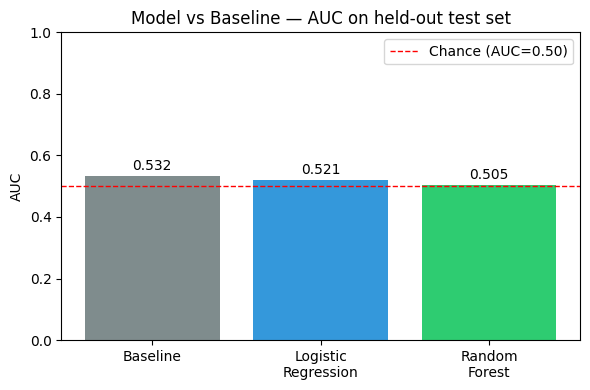

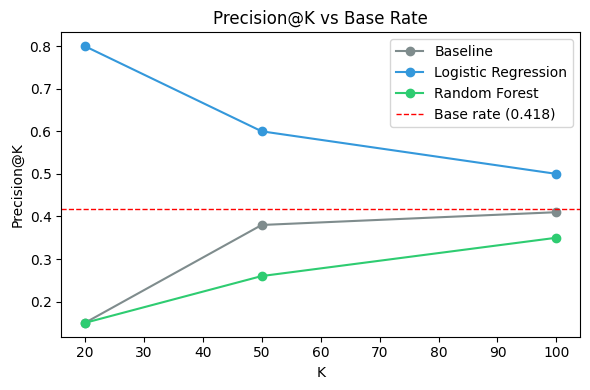

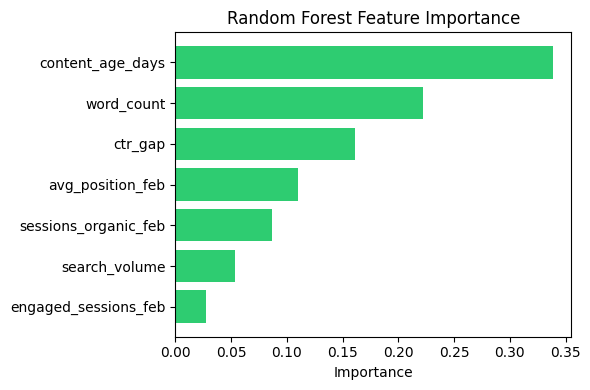

Saved 3 figures to work/figures/


In [9]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

# Chart 1: AUC comparison
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Baseline", "Logistic\nRegression", "Random\nForest"]
aucs = [baseline_auc, logreg_auc, rf_auc]
bars = ax.bar(methods, aucs, color=["#7f8c8d", "#3498db", "#2ecc71"])
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance (AUC=0.50)")
ax.set_ylabel("AUC")
ax.set_title("Model vs Baseline — AUC on held-out test set")
ax.set_ylim(0, 1)
ax.legend()
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center")
plt.tight_layout()
plt.savefig("work/figures/auc_comparison.png", dpi=150)
plt.show()

# Chart 2: Precision@K comparison
fig, ax = plt.subplots(figsize=(6, 4))
ks = precision_table["k"]
ax.plot(ks, precision_table["baseline_precision"], marker="o", label="Baseline", color="#7f8c8d")
ax.plot(ks, precision_table["logreg_precision"], marker="o", label="Logistic Regression", color="#3498db")
ax.plot(ks, precision_table["rf_precision"], marker="o", label="Random Forest", color="#2ecc71")
ax.axhline(y_test.mean(), color="red", linestyle="--", linewidth=1, label=f"Base rate ({y_test.mean():.3f})")
ax.set_xlabel("K")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K vs Base Rate")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/precision_at_k.png", dpi=150)
plt.show()

# Chart 3: Feature importance (Random Forest)
fig, ax = plt.subplots(figsize=(6, 4))
imp_sorted = importances.sort_values("importance")
ax.barh(imp_sorted["feature"], imp_sorted["importance"], color="#2ecc71")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()

print("Saved 3 figures to work/figures/")

# ML-12

## 5-Minute Demo Outline

### 0:00–0:45 — Problem
Introduce the research question: identifying content pages that are most likely to decline in organic search performance so editors can prioritize refresh efforts efficiently.

### 0:45–2:00 — Data & Method
Briefly explain the FlyRank internship warehouse, the February→March prediction setup, engineered features (ranking position, CTR gap, content age, search volume, sessions, and word count), the baseline rule, and the two machine learning models (Logistic Regression and Random Forest).

### 2:00–3:30 — Results
Present the evaluation results. Explain that after correcting the floor-effect artifact by excluding pages with fewer than five February clicks, all methods performed close to chance level. Highlight that this negative result is valuable because it prevents deploying an unreliable ranking system.

### 3:30–4:30 — Recommendations
Recommend keeping human editorial review as the primary decision process while treating the baseline rule only as a lightweight triage tool. Suggest collecting richer longitudinal and competitive SEO features for future work.

### 4:30–5:00 — Closing
Summarize that the project demonstrates a complete and reproducible machine learning workflow while emphasizing careful validation, leakage prevention, and honest reporting of results.

---

## Social Post

I completed my FlyRank ML Internship capstone by investigating whether historical SEO and content signals can predict future declines in organic search performance.

The project compared a transparent baseline with Logistic Regression and Random Forest using a client-grouped evaluation strategy. After correcting an important floor-effect artifact, none of the tested methods outperformed chance, highlighting the importance of rigorous validation and honest reporting rather than chasing optimistic metrics.

This experience strengthened my understanding of feature engineering, leakage prevention, reproducible machine learning workflows, and evidence-based decision support.

---

## Employer-Facing Summary

Built an end-to-end machine learning research project using Python, DuckDB, and scikit-learn to investigate prediction of declining organic search performance using the FlyRank internship data warehouse.

Designed a reproducible evaluation pipeline with grouped train/test splitting, engineered SEO features, compared a transparent baseline with machine learning models, identified and corrected a major floor-effect artifact, and reported a validated negative result using appropriate evaluation metrics.

This project demonstrates practical experience with feature engineering, model evaluation, data leakage prevention, reproducible experimentation, and technical communication.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
